In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from src.common.load_data import load_data, drop_targets, get_test_sets
from src.common.treat_missing import load_and_process_for_random_forest
from src.common.evaluations import evaluate_classification
from src.utils.plots import plot_loss_curve, plot_roc_auc_curve, plot_precision_recall_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.options.display.max_rows = 200

## Check further for P3 and P4 bad performance

**How to fix overfitting in Random Forest?**

| If your model is overfitting | Action to take on Hyperparameter |
|---|---|
| max_depth | Decrease it (e.g., from None to 10)|
| min_samples_leaf | Increase it (e.g., from 1 to 5) |
| min_samples_split | Increase it (e.g., from 2 to 10) |
| max_features | Decrease it (e.g., from 1.0 to 'sqrt') | 
| ccp_alpha | Increase it (e.g., from 0.0 to 0.01) |

## 1. Load Data

In [2]:
df = load_data("./data/cibil_score/cibil_score.csv")
X, y_lin_reg, y_binary, y_multiclass = drop_targets(df)
X_train, X_test, y_train, y_test = get_test_sets(X, y_multiclass, test_size=0.3)

0


## 2. Preprocessing

In [3]:
X_train_processed, X_test_processed = load_and_process_for_random_forest(X_train, X_test)

2026-09-02 10:10:01,046 [INFO] src.common.treat_missing: No columns exceeded the 95% null threshold; none dropped.
2026-09-02 10:10:01,148 [INFO] src.common.treat_missing: Fitted OrdinalEncoder on 5 categorical column(s): ['maritalstatus', 'education', 'gender', 'last_prod_enq2', 'first_prod_enq2']
2026-09-02 10:10:01,149 [INFO] src.common.treat_missing: TreeModelPreprocessor fit complete.
2026-09-02 10:10:01,418 [INFO] src.common.treat_missing: Random-forest data processing complete (no validation split; use oob_score=True for held-out estimates).


## 3. Random Forest Multiclass Classifier

In [4]:
rf_multiclass = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)


rf_multiclass.fit(
    X_train_processed,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['P1','P2','P3','P4']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](85,)","['prospectid','total_tl','tot_closed_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,85
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


## 4. Random Forest Multiclass Classifier with class_weight "balanced"

In [5]:
rf_multiclass1 = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_multiclass1.fit(
    X_train_processed,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['P1','P2','P3','P4']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](85,)","['prospectid','total_tl','tot_closed_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,85
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


## 5. Random Forest Multiclass Classifier with custom class_weight

In [6]:
class_weight={
    "P1": 1.0,
    "P2": 0.5,
    "P3": 2.0,
    "P4": 1.0
}

rf_multiclass2 = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight=class_weight,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


rf_multiclass2.fit(
    X_train_processed,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['P1','P2','P3','P4']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](85,)","['prospectid','total_tl','tot_closed_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,85
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


## 6. Evaluate all three variants of Multiclass Models

In [7]:
multiclass_results = evaluate_classification(
    rf_multiclass,
    X_test_processed,
    y_test,
    binary=False
)

print("\n==============================")
print("Random Forest Multiclass")
print("==============================")

for metric, value in multiclass_results.items():
    print(f"{metric}: {value}")

multiclass_results1 = evaluate_classification(
    rf_multiclass1,
    X_test_processed,
    y_test,
    binary=False
)

print("\n================================================")
print("Random Forest Multiclass class-weight='balanced'")
print("==================================================")

for metric, value in multiclass_results1.items():
    print(f"{metric}: {value}")

multiclass_results2 = evaluate_classification(
    rf_multiclass2,
    X_test_processed,
    y_test,
    binary=False
)

print("\n==============================================")
print("Random Forest Multiclass custom class-weight")
print("================================================")

for metric, value in multiclass_results2.items():
    print(f"{metric}: {value}")

              precision    recall  f1-score   support

          P1       0.88      0.61      0.72       851
          P2       0.78      0.97      0.87      4791
          P3       0.50      0.15      0.23      1139
          P4       0.76      0.72      0.74       920

    accuracy                           0.78      7701
   macro avg       0.73      0.61      0.64      7701
weighted avg       0.75      0.78      0.74      7701


Random Forest Multiclass
accuracy: 0.7753538501493312
f1_macro: 0.63721940187139
precision_macro: 0.7297063014445195
recall_macro: 0.609585553177011
precision_weighted: 0.7490093656258889
recall_weighted: 0.7753538501493312
f1_weighted: 0.7394783218112697
confusion_matrix: [[ 516  335    0    0]
 [  56 4625   68   42]
 [  14  784  170  171]
 [   1  157  102  660]]
              precision    recall  f1-score   support

          P1       0.58      0.96      0.72       851
          P2       0.95      0.64      0.77      4791
          P3       0.37      0.64 

Random Forest Multiclass

|Macro F1 | P3 Recall |
|---|---|
| No class weights | 0.626 | 12.2% |
| Balanced | 0.651 | 58.9% |
| Custom weights | 0.682 | 77.7% |

## 7. Random Search for Best Parameters

In [8]:
class_weight = {
    "P1": 1.0,
    "P2": 0.5,
    "P3": 2.0,
    "P4": 1.0
}

param_distributions = {
    "model__n_estimators": [100, 200, 300], # dropped 400, 500
    "model__max_depth": [5, 8, 10, 12, 15, 20], # dropped None and 30 
    "model__min_samples_split": [5, 10, 15, 20], # dropped 2
    "model__min_samples_leaf": [2, 4, 6, 8], # dropped 1
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7], # dropped 1.0
    "model__ccp_alpha": [0.001, 0.01, 0.05], # dropped 0.0
}

rf_search_base = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        ))
    ]
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_search_base,
    param_distributions=param_distributions,
    n_iter=20, # drop from 50
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), # drop from 5
    verbose=3, # Gives step wise logs
    random_state=RANDOM_STATE,
    n_jobs=-2
)

rf_random_search.fit(X_train_processed, y_train)

print("Best Parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV Score (Macro F1): {rf_random_search.best_score_:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 2/3] END model__ccp_alpha=0.001, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=8, model__min_samples_split=15, model__n_estimators=300;, score=nan total time= 1.8min
[CV 1/3] END model__ccp_alpha=0.001, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=8, model__min_samples_split=15, model__n_estimators=300;, score=nan total time= 1.9min
[CV 3/3] END model__ccp_alpha=0.001, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=8, model__min_samples_split=15, model__n_estimators=300;, score=nan total time= 1.9min
[CV 2/3] END model__ccp_alpha=0.05, model__max_depth=12, model__max_features=0.5, model__min_samples_leaf=6, model__min_samples_split=10, model__n_estimators=200;, score=nan total time= 2.4min
[CV 3/3] END model__ccp_alpha=0.05, model__max_depth=12, model__max_features=0.5, model__min_samples_leaf=6, model__min_samples_split=10, model__n_estimators=200;, 

## 8. Run Regression Using Best Parameters

In [9]:
# Strip the pipeline step prefix ("model__") so the params can be passed
# straight into a fresh RandomForestClassifier
best_params = {
    k.replace("model__", ""): v for k, v in rf_random_search.best_params_.items()
}

rf_best = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            **best_params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]
)

rf_best.fit(X_train_processed, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['P1','P2','P3','P4']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](85,)","['prospectid','total_tl','tot_closed_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,85
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15


## 9. Plot Train and Test Loss Curve - Model with best parameters

n_estimators evaluated at each step: [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]


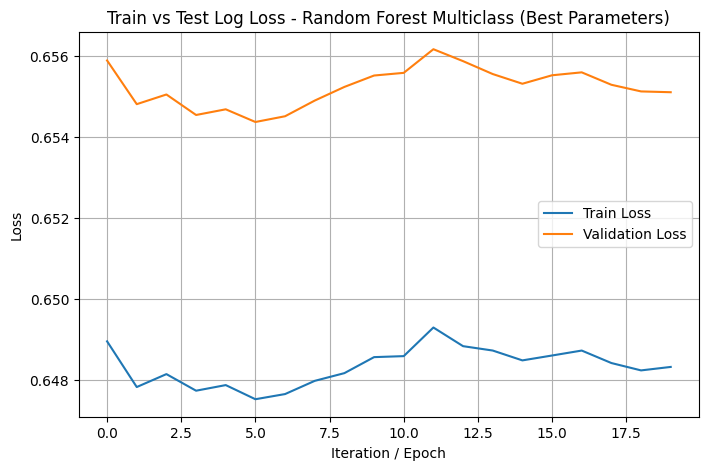

In [10]:
from sklearn.metrics import log_loss

# RandomForestClassifier has no staged/iterative loss the way boosting models
# do, so we track train/test log loss as trees are added using `warm_start`,
# then hand the two loss lists to the shared `plot_loss_curve` helper.
warm_start_params = {k: v for k, v in best_params.items() if k != "n_estimators"}
target_n_estimators = best_params.get("n_estimators", 200)

step = max(target_n_estimators // 20, 1)
n_estimators_range = list(range(step, target_n_estimators + step, step))

rf_warm = RandomForestClassifier(
    **warm_start_params,
    class_weight=class_weight,
    warm_start=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_losses = []
test_losses = []

for n_est in n_estimators_range:
    rf_warm.set_params(n_estimators=n_est)
    rf_warm.fit(X_train_processed, y_train)
    train_proba = rf_warm.predict_proba(X_train_processed)
    test_proba = rf_warm.predict_proba(X_test_processed)
    train_losses.append(log_loss(y_train, train_proba, labels=rf_warm.classes_))
    test_losses.append(log_loss(y_test, test_proba, labels=rf_warm.classes_))

print(f"n_estimators evaluated at each step: {n_estimators_range}")

plot_loss_curve(
    train_losses,
    test_losses,
    title="Train vs Test Log Loss - Random Forest Multiclass (Best Parameters)",
)


## 11. Plot ROC-AUC Curve - Model with best parameters

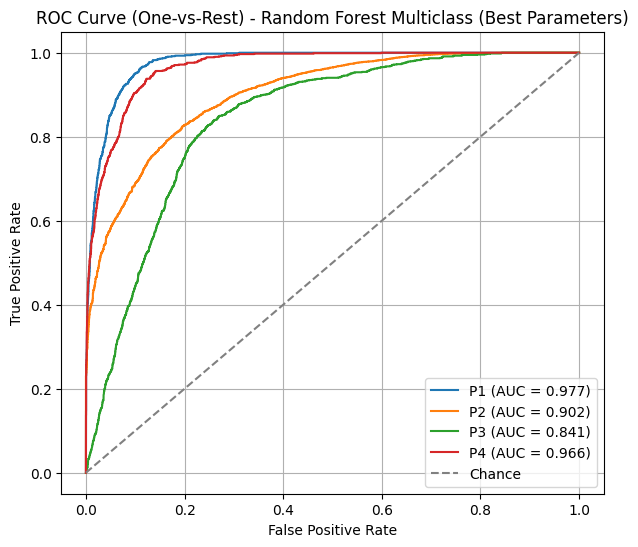

In [11]:
class_labels = rf_best.classes_.tolist()
y_test_scores = rf_best.predict_proba(X_test_processed)

plot_roc_auc_curve(
    y_test,
    y_test_scores,
    classes=class_labels,
    title="ROC Curve (One-vs-Rest) - Random Forest Multiclass (Best Parameters)",
)


## 12. Plot Precision-Recall Curve - Model with best parameters

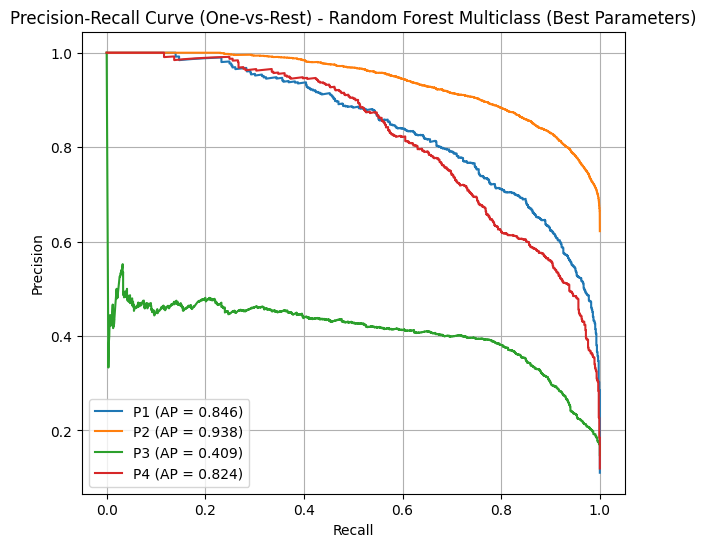

In [12]:
plot_precision_recall_curve(
    y_test,
    y_test_scores,
    classes=class_labels,
    title="Precision-Recall Curve (One-vs-Rest) - Random Forest Multiclass (Best Parameters)",
)


## 13. Evaluate Binary Classification - Model with best parameters

In [13]:
multiclass_results_best = evaluate_classification(
    rf_best,
    X_test_processed,
    y_test,
    binary=False
)

print("\n==============================")
print("Random Forest Multiclass - Best Parameters")
print("==============================")

for metric, value in multiclass_results_best.items():
    print(f"{metric}: {value}")


              precision    recall  f1-score   support

          P1       0.67      0.85      0.75       851
          P2       0.93      0.69      0.79      4791
          P3       0.36      0.83      0.51      1139
          P4       0.90      0.46      0.61       920

    accuracy                           0.70      7701
   macro avg       0.71      0.71      0.66      7701
weighted avg       0.81      0.70      0.72      7701


Random Forest Multiclass - Best Parameters
accuracy: 0.698221010258408
f1_macro: 0.66217653777986
precision_macro: 0.7145367493432835
recall_macro: 0.7059049003034682
precision_weighted: 0.810960853090151
recall_weighted: 0.698221010258408
f1_weighted: 0.720196336663447
confusion_matrix: [[ 723  124    4    0]
 [ 324 3287 1163   17]
 [  31  131  947   30]
 [   2   10  488  420]]


## 14. Important Features

In [14]:
# Which features did the tree model use most?

rf_model = rf_multiclass2.named_steps["model"]

feature_names = rf_multiclass2.feature_names_in_

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(20))

age_oldest_tl                   0.122974
enq_l3m                         0.106597
time_since_recent_enq           0.074989
enq_l6m                         0.061680
num_std                         0.049306
num_std_12mts                   0.043261
time_since_recent_deliquency    0.035753
enq_l12m                        0.034144
num_std_6mts                    0.033146
pct_pl_enq_l6m_of_ever          0.023869
pl_enq_l6m                      0.023775
time_since_first_deliquency     0.022751
pct_pl_enq_l6m_of_l12m          0.021654
total_tl                        0.018623
recent_level_of_deliq           0.017358
max_delinquency_level           0.017349
tot_closed_tl                   0.016550
secured_tl                      0.016245
num_times_delinquent            0.015886
max_recent_level_of_deliq       0.015885
dtype: float64


In [15]:
# Which original input features actually matter for my final model?

result = permutation_importance(
    rf_multiclass2,
    X_train_processed,
    y_train,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X_test_processed.columns
).sort_values(ascending=False)

print(importance.head(20))

age_oldest_tl                   0.108279
enq_l3m                         0.086000
time_since_recent_enq           0.036956
enq_l6m                         0.024349
time_since_recent_deliquency    0.018815
num_std_12mts                   0.012164
num_std                         0.012148
pct_pl_enq_l6m_of_ever          0.011073
enq_l12m                        0.011028
pct_pl_enq_l6m_of_l12m          0.008667
pl_enq_l6m                      0.007504
time_since_first_deliquency     0.007100
num_std_6mts                    0.007028
max_delinquency_level           0.005961
tot_enq                         0.004950
total_tl                        0.004703
pct_tl_open_l12m                0.004558
recent_level_of_deliq           0.004407
max_deliq_12mts                 0.004287
pl_enq_l12m                     0.003659
dtype: float64


## 13. Evaluate Regression with important features and best parameters

In [16]:
important_features = importance[importance > importance.mean()].index.tolist()

print(f"Selected {len(important_features)} important features out of {X_train_processed.shape[1]}:")
print(important_features)

X_train_important = X_train_processed[important_features]
X_test_important = X_test_processed[important_features]

rf_best_important = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            **best_params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]
)

rf_best_important.fit(X_train_important, y_train)

multiclass_results_important = evaluate_classification(
    rf_best_important,
    X_test_important,
    y_test,
    binary=False
)

print("\n==============================")
print("Random Forest Multiclass - Best Parameters + Important Features")
print("==============================")

for metric, value in multiclass_results_important.items():
    print(f"{metric}: {value}")


Selected 14 important features out of 85:
['age_oldest_tl', 'enq_l3m', 'time_since_recent_enq', 'enq_l6m', 'time_since_recent_deliquency', 'num_std_12mts', 'num_std', 'pct_pl_enq_l6m_of_ever', 'enq_l12m', 'pct_pl_enq_l6m_of_l12m', 'pl_enq_l6m', 'time_since_first_deliquency', 'num_std_6mts', 'max_delinquency_level']
              precision    recall  f1-score   support

          P1       0.67      0.81      0.74       851
          P2       0.92      0.68      0.78      4791
          P3       0.36      0.84      0.50      1139
          P4       0.90      0.45      0.60       920

    accuracy                           0.69      7701
   macro avg       0.71      0.69      0.65      7701
weighted avg       0.81      0.69      0.71      7701


Random Forest Multiclass - Best Parameters + Important Features
accuracy: 0.688222308791066
f1_macro: 0.6535034966277081
precision_macro: 0.7111984745967033
recall_macro: 0.6942922328458445
precision_weighted: 0.8054176739290448
recall_weighted: 0

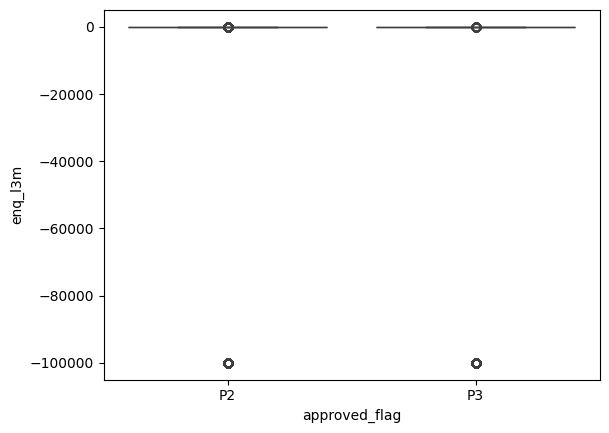

In [17]:
feature = "enq_l3m"

sns.boxplot(
    data=df[df["approved_flag"].isin(["P2", "P3"])],
    x="approved_flag",
    y=feature
)

plt.show()

In [18]:
features = ["age_oldest_tl", "enq_l3m", "enq_l6m", "time_since_recent_enq", "time_since_recent_deliquency", "pl_enq_l6m", "pct_pl_enq_l6m_of_ever", "time_since_first_deliquency", "num_std", "num_std_12mts", "num_std_6mts", "pct_pl_enq_l6m_of_l12m", "enq_l12m", "max_recent_level_of_deliq"]

df.groupby("approved_flag")[features].mean()

,age_oldest_tl,enq_l3m,enq_l6m,time_since_recent_enq,time_since_recent_deliquency,pl_enq_l6m,pct_pl_enq_l6m_of_ever,time_since_first_deliquency,num_std,num_std_12mts,num_std_6mts,pct_pl_enq_l6m_of_l12m,enq_l12m,max_recent_level_of_deliq
approved_flag,,,,,,,,,,,,,,
P1,108.784077,-13906.121661,-13905.794072,-13365.022402,-75113.091677,-13906.338446,0.043185,-75110.178701,36.044804,12.747200,5.431329,0.062123,-13905.157677,16.678098
P2,-74.769247,-15425.225193,-15424.747818,-15193.733377,-76741.195596,-15425.575608,0.099268,-76739.231839,6.817945,2.523463,1.158204,0.114041,-15424.005280,9.907482
P3,-8.530596,-5191.674047,-5190.795625,-5076.559179,-55830.913043,-5192.545357,0.298835,-55828.296430,4.209340,1.457595,0.683709,0.324706,-5189.730945,16.322061
P4,28.474668,-2715.977219,-2714.259436,-2682.198062,-46199.539952,-2718.366202,0.523383,-46196.540292,2.119007,0.734444,0.387283,0.564922,-2712.526862,26.646889


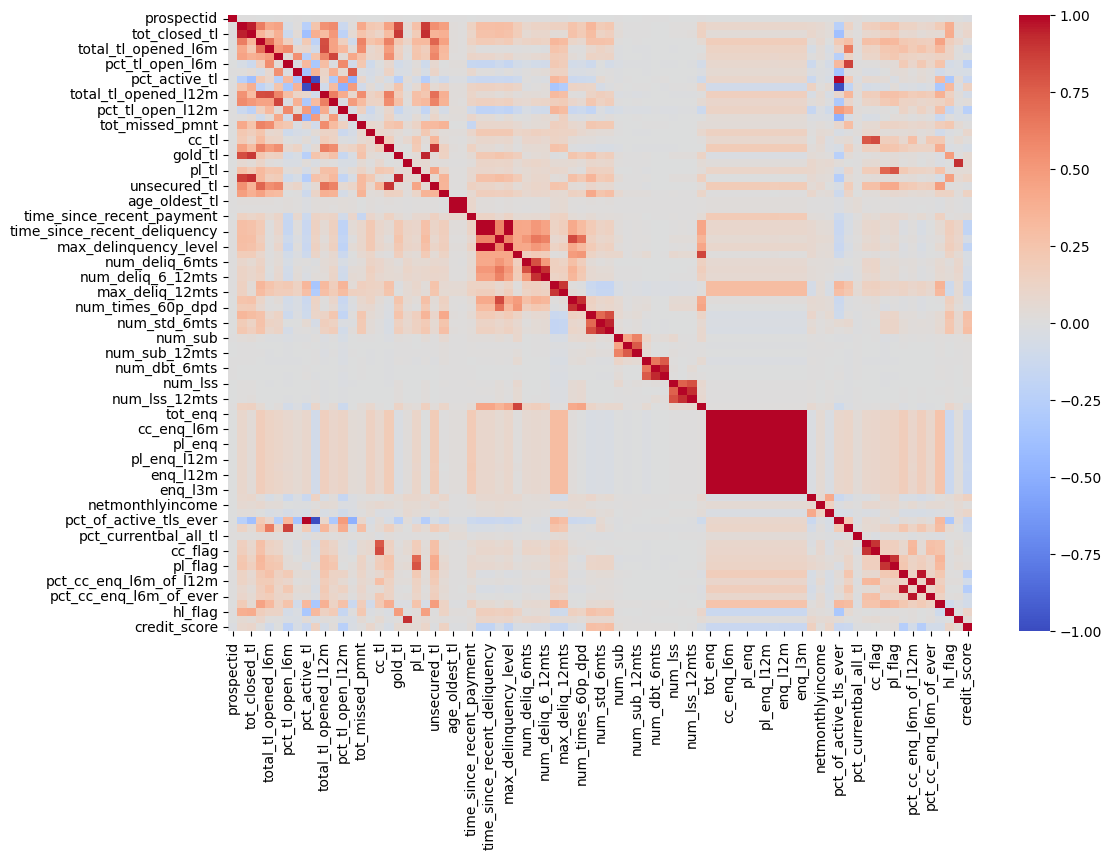

In [19]:
df_p2_p3 = df[df["approved_flag"].isin(["P2", "P3"])]

corr = df_p2_p3.select_dtypes("number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()